In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pickle

print("✅ Libraries imported!")

✅ Libraries imported!


In [3]:
# Load built in breast cancer dataset
data = load_breast_cancer()

# Convert to dataframe
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

print("Shape:", df.shape)
print("\nTarget:")
print("0 = Malignant (Cancer)")
print("1 = Benign (No Cancer)")
print("\nTarget Distribution:")
print(df['target'].value_counts())
df.head()

Shape: (569, 31)

Target:
0 = Malignant (Cancer)
1 = Benign (No Cancer)

Target Distribution:
target
1    357
0    212
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [4]:
print("Missing Values:")
print(df.isnull().sum().sum())

print("\nFeature Names:")
for i, name in enumerate(data.feature_names):
    print(f"{i+1}. {name}")

Missing Values:
0

Feature Names:
1. mean radius
2. mean texture
3. mean perimeter
4. mean area
5. mean smoothness
6. mean compactness
7. mean concavity
8. mean concave points
9. mean symmetry
10. mean fractal dimension
11. radius error
12. texture error
13. perimeter error
14. area error
15. smoothness error
16. compactness error
17. concavity error
18. concave points error
19. symmetry error
20. fractal dimension error
21. worst radius
22. worst texture
23. worst perimeter
24. worst area
25. worst smoothness
26. worst compactness
27. worst concavity
28. worst concave points
29. worst symmetry
30. worst fractal dimension


C:\Users\Ikram Ul Haq\AppData\Local\Temp\ipykernel_7412\1209414091.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=df, palette='coolwarm')


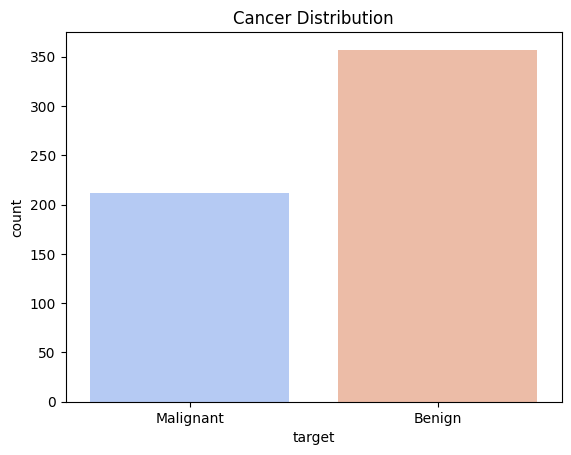

In [5]:
sns.countplot(x='target', data=df, palette='coolwarm')
plt.title('Cancer Distribution')
plt.xticks([0, 1], ['Malignant', 'Benign'])
plt.show()

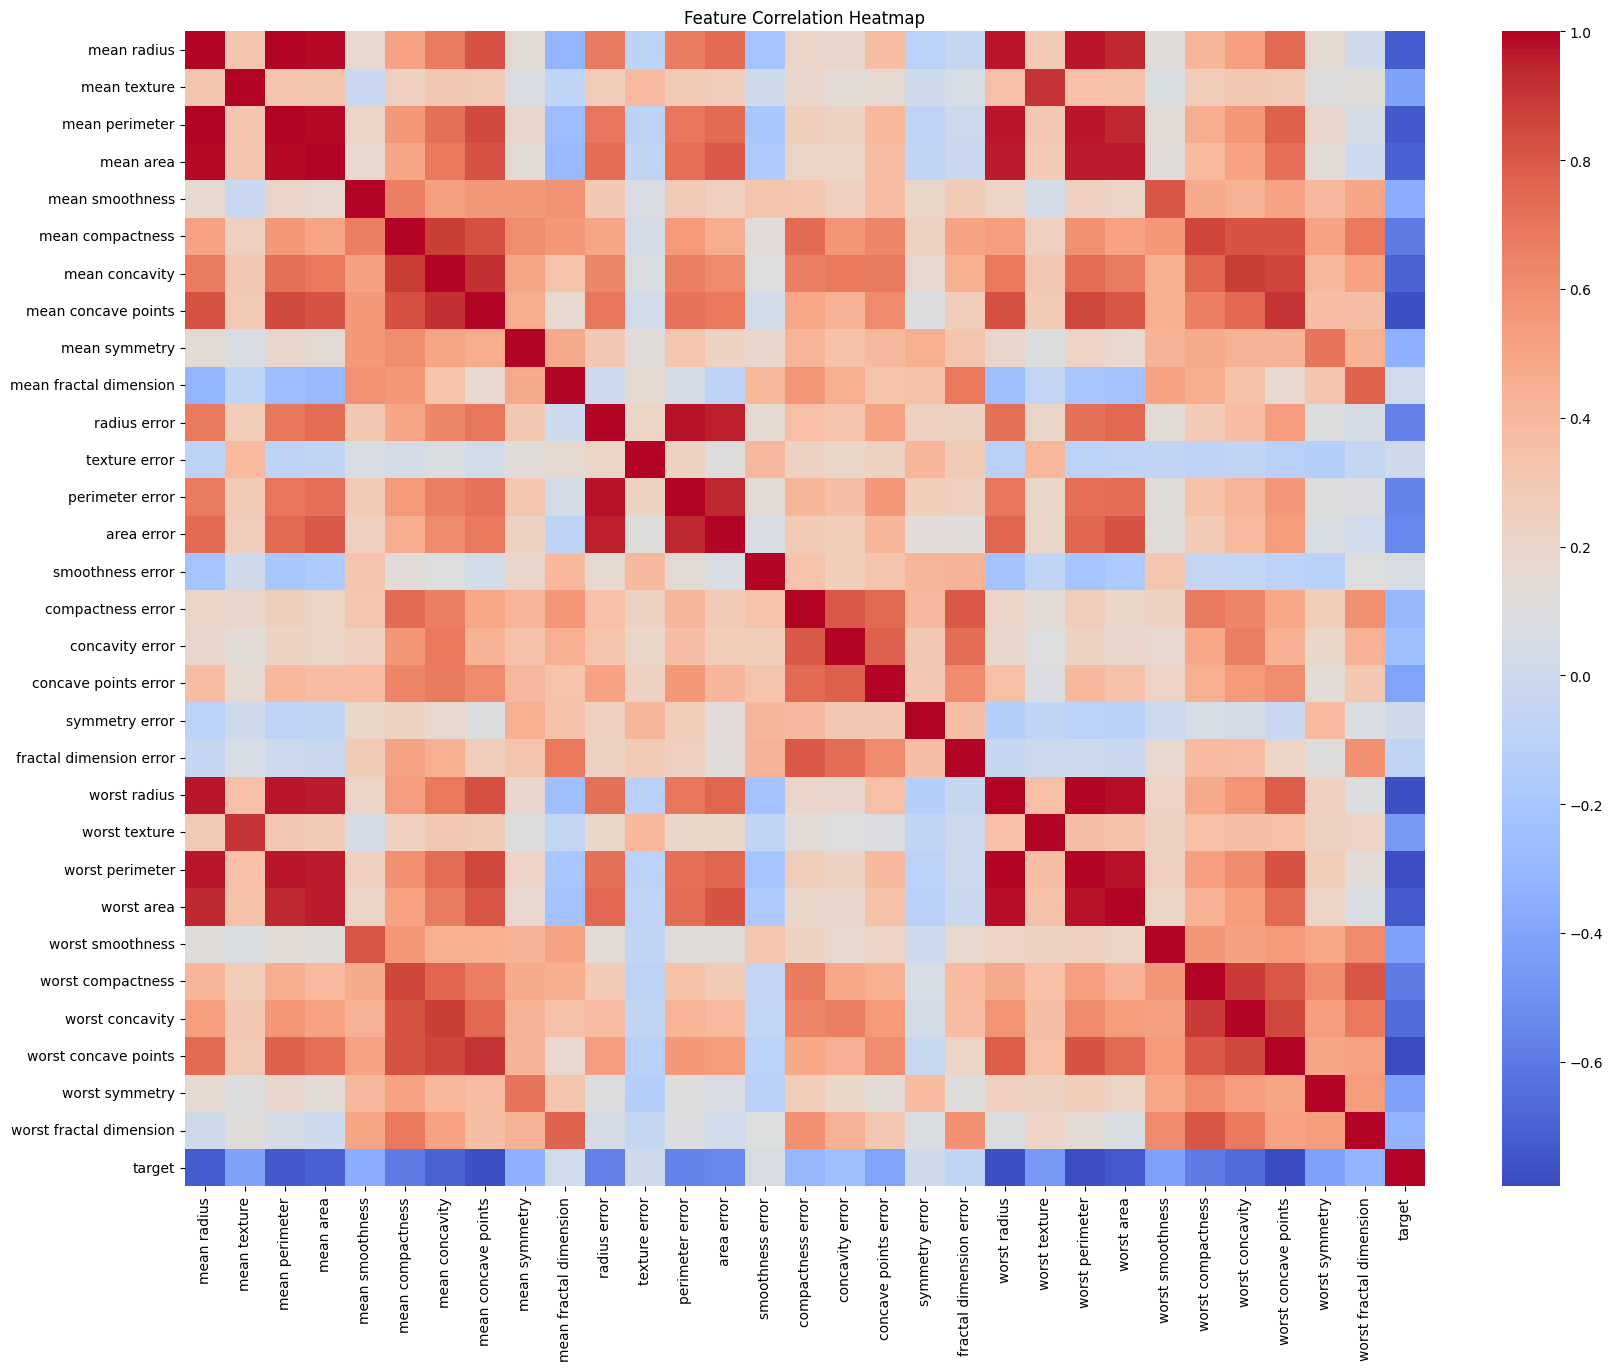

In [6]:
plt.figure(figsize=(20, 15))
sns.heatmap(df.corr(), annot=False, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

In [7]:
X = data.data
y = data.target

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (569, 30)
Target shape: (569,)


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(f"Train size: {X_train.shape}")
print(f"Test size:  {X_test.shape}")

Train size: (455, 30)
Test size:  (114, 30)


In [9]:
scaler_cancer = StandardScaler()
X_train = scaler_cancer.fit_transform(X_train)
X_test = scaler_cancer.transform(X_test)

print("✅ Data scaled!")

✅ Data scaled!


In [10]:
model_cancer = MLPClassifier(
    hidden_layer_sizes=(100, 50),
    max_iter=1000,
    random_state=42
)

model_cancer.fit(X_train, y_train)
print("✅ Model trained!")

✅ Model trained!


In [11]:
y_pred = model_cancer.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"✅ Accuracy: {accuracy * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Malignant', 'Benign']))

✅ Accuracy: 97.37%

Classification Report:
              precision    recall  f1-score   support

   Malignant       0.98      0.95      0.96        43
      Benign       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



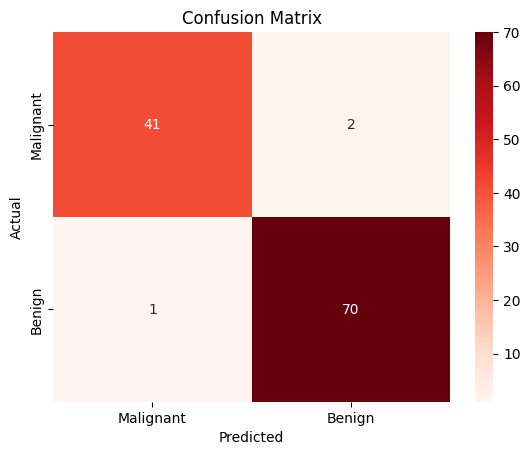

In [12]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Malignant', 'Benign'],
            yticklabels=['Malignant', 'Benign'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [13]:
def predict_cancer(patient_data):
    print("=" * 40)
    print("   BREAST CANCER PREDICTION")
    print("=" * 40)

    patient_scaled = scaler_cancer.transform([patient_data])
    prediction = model_cancer.predict(patient_scaled)[0]
    proba = model_cancer.predict_proba(patient_scaled)[0]
    confidence = max(proba) * 100

    if prediction == 0:
        print(f"\n🔴 MALIGNANT (Cancer) detected!")
        print(f"📊 Confidence: {confidence:.2f}%")
    else:
        print(f"\n🟢 BENIGN (No Cancer)")
        print(f"📊 Confidence: {confidence:.2f}%")
    print("=" * 40)

# Test with first patient from dataset
predict_cancer(data.data[0])

   BREAST CANCER PREDICTION

🔴 MALIGNANT (Cancer) detected!
📊 Confidence: 100.00%


In [14]:
pickle.dump(model_cancer, open('model_cancer.sav', 'wb'))
pickle.dump(scaler_cancer, open('scaler_cancer.sav', 'wb'))
print("✅ Model and scaler saved!")

✅ Model and scaler saved!


In [1]:
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
import pickle

# Reload data
data = load_breast_cancer()
X = data.data

# Recreate scaler
scaler_cancer = StandardScaler()
scaler_cancer.fit(X)

# Save again
pickle.dump(scaler_cancer, open('scaler_cancer.sav', 'wb'))
print("✅ Scaler recreated and saved!")

✅ Scaler recreated and saved!
